# QFLS and light-intensity dependant JV fits perovskite solar cell (real data)
This notebook is a demonstration of how to fit light-intensity dependent QFLS and JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.  

It uses real experimental data from perovskite solar cells taken from the following publication:  
Grabowski, D., Liu, Z., Schöpe, G., Rau, U. and Kirchartz, T. (2022), Fill Factor Losses and Deviations from the Superposition Principle in Lead Halide Perovskite Solar Cells. Sol. RRL, 6: 2200507. https://doi.org/10.1002/solr.202200507

In [ ]:
# Import necessary libraries
import warnings, os, sys, shutil,torch, copy
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
# from linear_operator.utils.warnings import NumericalWarning
# warnings.filterwarnings("ignore", category=NumericalWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore',module='linear_operator')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from itertools import combinations
from pySIMsalabim.experiments.JV_steady_state import *
from ax.utils.notebook.plotting import init_notebook_plotting
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 04-02 13:36:12] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 04-02 13:36:12] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Get the experimental data

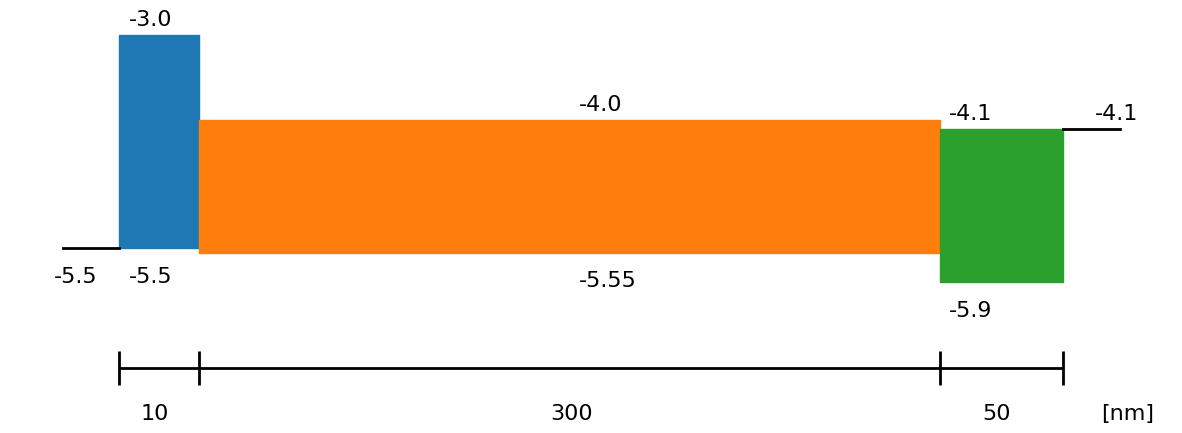

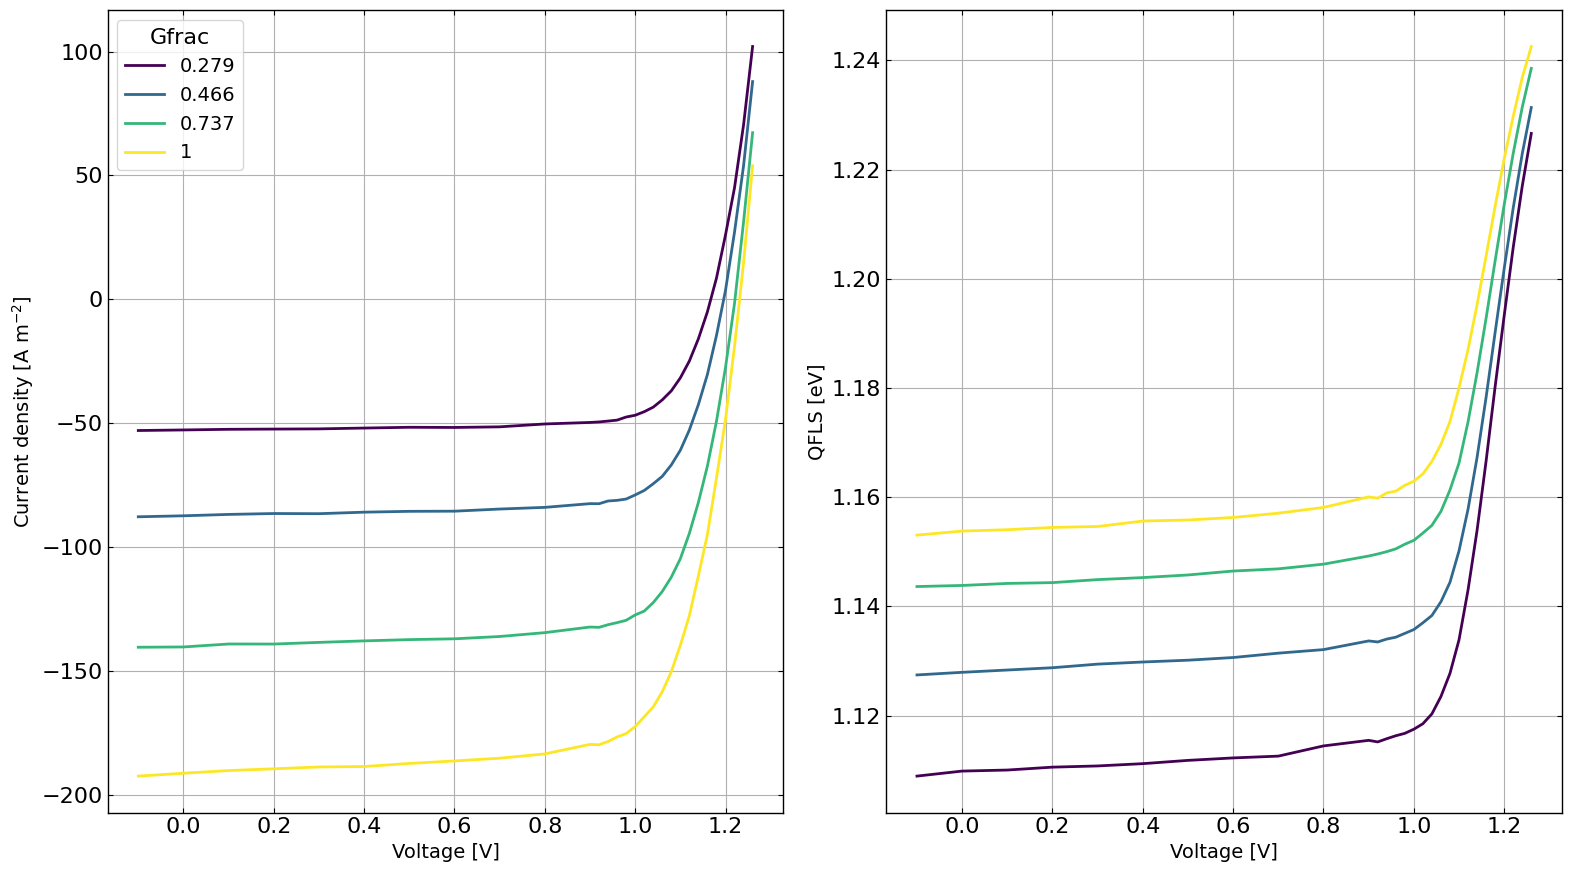

In [2]:
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','pero_JV_QFLS')))
simulation_setup_filename = 'simulation_setup_K.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 
optical_files = ['nk_glass.txt','nk_ITO.txt','nk_PTAA.txt','nk_MAPI.txt','nk_C60_1.txt','nk_Ag.txt']
# path to the layer files defined in the simulation_setup file
l1 = 'PTAA_K.txt'
l2 = 'MAPI_K.txt'
l3 = 'C60_K.txt'
l1 = os.path.join(input_path, l1)
l2 = os.path.join(input_path, l2)
l3 = os.path.join(input_path, l3)

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)
# copy the optical files to the session path
for file in optical_files:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))


# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)
dev_par, layers = sim.load_device_parameters(session_path, simulation_setup, run_mode = False)
SIMsalabim_params  = {}
for layer in layers:
    SIMsalabim_params[layer[1]] = sim.ReadParameterFile(os.path.join(session_path,layer[2]))
L_active_Layer = float(SIMsalabim_params['l2']['L'])

# Load the JV data
X,X_QFLS = [],[]
y,y_QFLS = [],[]

JVs_exp = ['JV_0_279.txt','JV_0_466.txt','JV_0_737.txt','JV_1.txt']
QFLS_exp = ['QFLS_0_279.txt','QFLS_0_466.txt','QFLS_0_737.txt','QFLS_1.txt']
Gfracs = [0.279,0.466,0.737,1]

for i in range(len(JVs_exp)):
    df = pd.read_csv(os.path.join(input_path, JVs_exp[i]),delim_whitespace=True)
    df = df.dropna()
    df_qfls = pd.read_csv(os.path.join(input_path, QFLS_exp[i]),delim_whitespace=True)
    df_qfls = df_qfls.dropna()
    df['Gfrac'] = Gfracs[i]*np.ones(len(df))
    df_qfls['Gfrac'] = Gfracs[i]*np.ones(len(df_qfls))
    if i == 0:
        X = np.asarray(df[['Vext','Gfrac']])
        X_QFLS = np.asarray(df_qfls[['Vext','Gfrac']])
        y = np.asarray(df['Jext'].values*10)
        y_QFLS = np.asarray(df_qfls['QFLS'].values)
    else:
        X = np.vstack((X,df[['Vext','Gfrac']]))
        X_QFLS = np.vstack((X_QFLS,df_qfls[['Vext','Gfrac']]))
        y = np.hstack((y,df['Jext'].values*10))
        y_QFLS = np.hstack((y_QFLS,df_qfls['QFLS'].values))

X = np.asarray(X)
y = np.asarray(y)
X_QFLS = np.asarray(X_QFLS)
y_QFLS = np.asarray(y_QFLS)

# get 1sun Jsc as it will help narrow down the range for Gehp
Jsc_1sun = np.interp(0.0, X[X[:,1] == 1][:,0], y[X[:,1] == 1])
minJ = np.min(y) 
q = constants.value(u'elementary charge')
G_ehp_calc = abs(Jsc_1sun/(q*L_active_Layer))
G_ehp_max = abs(minJ/(q*L_active_Layer))

# plot the data for each Gfrac
fig, axes = plt.subplots(1,2, figsize=(16,9))
viridis = plt.get_cmap('viridis', len(Gfracs))
for gfrac in Gfracs:
    axes[0].plot(X[X[:,1] == gfrac][:,0], y[X[:,1] == gfrac],'-',label=str(gfrac), color=viridis(Gfracs.index(gfrac)))

axes[0].legend(title='Gfrac')
axes[0].grid()
axes[0].set_xlabel('Voltage [V]')
axes[0].set_ylabel('Current density [A m$^{-2}$]')
# plt.show()

for gfrac in Gfracs:
    axes[1].plot(X_QFLS[X_QFLS[:,1] == gfrac][:,0], y_QFLS[X_QFLS[:,1] == gfrac],'-',label=str(gfrac), color=viridis(Gfracs.index(gfrac)))
axes[1].grid()
axes[1].set_xlabel('Voltage [V]')
axes[1].set_ylabel('QFLS [eV]')
plt.tight_layout()
plt.show()

## Define the parameters for the simulation

In [3]:
# Add Ions in TL
ionsinTLs = 1 # 1: ions can enter the transport layers, 0: ions cannot enter the transport layers
params = [] # list of parameters to be optimized

# Perovskite layer parameters
Nc = FitParam(name = 'l2.N_c', value = 3.15e24, bounds = [1e24,4e24], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_c$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = True,)
params.append(Nc)

mun = FitParam(name = 'l2.mu_n', value = 1.49e-5, bounds = [1e-6,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 1.905e-5, bounds = [1e-6,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_p$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1.3e17, bounds = [1e17,8e21], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T}$', unit='s', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(bulk_tr)

k_direct = FitParam(name = 'l2.k_direct', value = 2.5e-17, bounds = [1e-18,1e-15], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$k_{direct}$', unit='m$^{3}$ s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(k_direct)

Nions = FitParam(name = 'l2.C_cation', value = 2.77e23, bounds = [5e22,8e23], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{ions}$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(Nions) # Note: C_cation is not defined in SIMsalabim here this sets the N_cation density and the N_A to the same value, this is the equivalent of having the cations being free to move but the anions are immobile.

Gehp = FitParam(name = 'l2.G_ehp', value = 3.98e27, bounds = [G_ehp_calc*0.8,G_ehp_max*1.2], type='range', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$G_{ehp}$', unit='m$^{-3}$ s$^{-1}$', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(Gehp) #G_ehp_calc

eps_r = FitParam(name = 'l2.eps_r', value = 34, bounds = [30,40], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\epsilon_r$', unit='-', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(eps_r)

# HTL parameters
N_t_int_l1 = FitParam(name = 'l1.N_t_int', value = 1.23e10, bounds = [1e8,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{HTL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(N_t_int_l1)

offset_l2_l1 = FitParam(name = 'offset_l2_l1.E_v', value = 0.04, bounds = [0,0.1], values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\Delta E_{L2-L1}$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(offset_l2_l1)

Egap_l1 = FitParam(name = 'Egap_l1.E_c', value = 2.15, bounds = [2.1,2.2], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$E_{gap,L1}$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(Egap_l1)

eps_r_l1 = FitParam(name = 'l1.eps_r', value = 3.5, bounds = [2.5,4], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\epsilon_{r}^{HTL}$', unit='-', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(eps_r_l1)

Nc_l1 = FitParam(name = 'l1.Nc', value = 5.44e26, bounds = [1e26,1e27], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{c}^{HTL}$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(Nc_l1)

mu_HTL = FitParam(name = 'l1.mu_p', value = 5e-10, bounds = [5e-10,1e-7], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_{p}^{HTL}$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mu_HTL)

ionsMayEnter_HTL = FitParam(name = 'l1.ionsMayEnter', value = ionsinTLs, bounds = [0,1], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'int', fscale = None, rescale = False, stepsize = None, display_name=r'Ions in HTL', unit='-', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(ionsMayEnter_HTL)

# ETL parameters
N_t_int_l2 = FitParam(name = 'l2.N_t_int', value = 1.27e12, bounds = [1e8,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{ETL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(N_t_int_l2)

offset_l2_l3 = FitParam(name = 'offset_l2_l3.E_c', value = -0.054, bounds = [-0.1,0], values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\Delta E_{L2-L3}$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(offset_l2_l3)

Egap_l3 = FitParam(name = 'Egap_l3.E_v', value = 2.3, bounds = [2.25,2.35], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$E_{gap,L3}$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(Egap_l3)

eps_r_l3 = FitParam(name = 'l3.eps_r', value = 3.16, bounds = [3,6], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\epsilon_{r}^{ETL}$', unit='-', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(eps_r_l3)

Nc_l3 = FitParam(name = 'l3.Nc', value = 2.35e26, bounds = [1e26,1e27], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{c}^{ETL}$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(Nc_l3)

mu_ETL = FitParam(name = 'l3.mu_n', value = 4.06e-7, bounds = [5e-9,1e-6], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_{n}^{ETL}$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mu_ETL)

ionsMayEnter_ETL = FitParam(name = 'l3.ionsMayEnter', value = ionsinTLs, bounds = [0,1], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'int', fscale = None, rescale = False, stepsize = None, display_name=r'Ions in ETL', unit='-', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(ionsMayEnter_ETL)

# Contact parameters
R_series = FitParam(name = 'R_series', value = 2.98e-4, bounds = [1e-6,1e-2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = True)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 0.22, bounds = [1e-2,1e2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{shunt}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = True)
params.append(R_shunt)

offset_W_L = FitParam(name = 'offset_W_L.E_v', value = 0.0, bounds = [0,0.1], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\Delta W_L$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(offset_W_L)

offset_W_R = FitParam(name = 'offset_W_R.E_c', value = -0.0, bounds = [-0.1,0], type='fixed', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\Delta W_R$', unit='eV', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(offset_W_R)

# save the original parameters for later
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])

print('Number of free parameters: ',num_free_params)

Number of free parameters:  20


## Run the optimization

In the following, the JVAgent defines two objectives: the QFLS vs light intensity and the JV curves at different light intensities. The QFLS target here is specified as 'K_QFLSL2'. The means that we are using the QFLS data from layer 2 (the perovskite layer) and we use the formula from the [paper](https://doi.org/10.1002/solr.202200507) from T. Kirchartz's group (hence the 'K_') to calculate the QFLS.
The formula is:
\begin{equation}
QFLS(V) = kTln\left(\frac{\phi(V)}{\phi_{OC}}\right) + qV_{OC}
\end{equation}
where k is the Boltzmann constant, T is the temperature, q is the elementary charge, $\phi(V)$ is the photoluminescence emission at voltage V, $\phi_{OC}$ is the photoluminescence emission at open-circuit voltage and $V_{OC}$ is the open-circuit voltage.  

Note that one can also use QFLSL2 for the QFLS calculated directly from the quasi-Fermi levels in layer 2 (the perovskite layer) instead of using the formula from the paper. 

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
metric = 'nrmse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'

jv = JVAgent(params, [X,X_QFLS], [y,y_QFLS], session_path, simulation_setup, parallel = True, max_jobs = 4, metric = [metric,metric], loss = [loss,loss], minimize= [True,True], threshold=[0.1,0.3], exp_format=['JV','K_QFLSL2'])

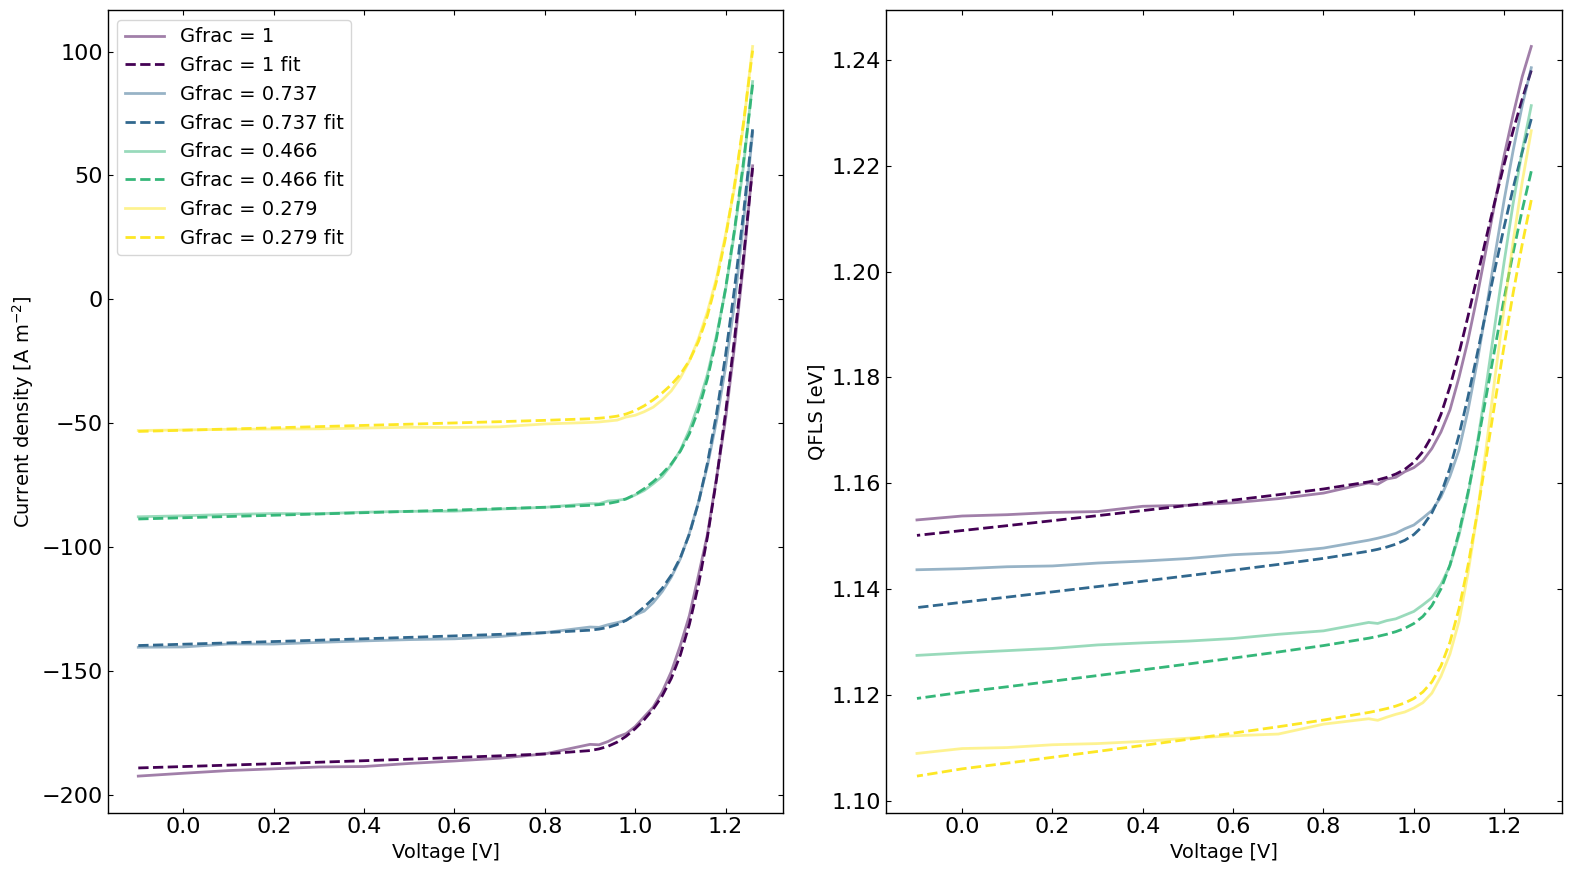

In [5]:
# run the simulation with some previously obtained parameters
yfit = jv.run(parameters={},exp_format='JV') # get the JV fit
yfit_QFLS = jv.run(parameters={},X=X_QFLS,exp_format='K_QFLSL2') # get the QFLS fit

viridis = plt.get_cmap('viridis', len(Gfracs))
fig, axes = plt.subplots(1,2, figsize=(16,9))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    axes[0].plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    axes[0].plot(X[X[:,1]==Gfrac,0],yfit[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
axes[0].set_xlabel('Voltage [V]')
axes[0].set_ylabel('Current density [A m$^{-2}$]')
axes[0].legend()
for idx, Gfrac in enumerate(Gfracs[::-1]):
    axes[1].plot(X_QFLS[X_QFLS[:,1]==Gfrac,0],y_QFLS[X_QFLS[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    axes[1].plot(X_QFLS[X_QFLS[:,1]==Gfrac,0],yfit_QFLS[X_QFLS[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
axes[1].set_xlabel('Voltage [V]')
axes[1].set_ylabel('QFLS [eV]')
plt.tight_layout()
plt.show()

In [6]:
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
from optimpv.optimizers.axBOtorch.axUtils import get_VMLC_default_model_kwargs_list
from optimpv.optimizers.axBOtorch.MorboGenerationNode import MorboGenerationNode
# Define the optimizer
n_init = 20#optimizer.n_batches[0] * optimizer.batch_size[0]
n_batches = [1,300]
batch_size = [n_init ,10]
total_trials = sum(b * s for b, s in zip(n_batches, batch_size))

# Reference point in raw loss space (adjust if your losses have a different scale)
reference_point = [0.2, 0.2] # must be provided

tkwargs = {
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'dtype': torch.double,
}

model_kwargs_list = [{},{'reference_point': reference_point,'max_evals': total_trials,'n_initial_points': n_init,'tr_hparam_overrides': {'min_tr_size': n_init,'max_tr_size': max(200, n_init),'n_trust_regions': 10,'raw_samples': 1024,}}]
# Define the optimizer
optimizer = axBOtorchOptimizer(params = params, agents = jv, models = ['SOBOL','MORBO'],n_batches = n_batches, batch_size = batch_size, model_kwargs_list = model_kwargs_list)

In [7]:
%%time
optimizer.optimize() # run the optimization with ax

[INFO 03-11 11:41:42] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'l2.N_c': 24.282106680188612, 'l2.mu_n': -4.562190815806389, 'l2.mu_p': -5.162624009884894, 'l2.N_t_bulk': 19.161789630612528, 'l2.k_direct': -16.77176074963063, 'l2.C_cation': 22.88264354312499, 'l2.G_ehp': 3.758352359417153e+27, 'l2.eps_r': 31.571824227296126, 'l1.N_t_int': 9.596054430119693, 'offset_l2_l1.E_v': 0.021923471149057152, 'l1.eps_r': 3.852914823913307, 'l1.Nc': 26.18255640938878, 'l1.mu_p': -8.297713044986871, 'l2.N_t_int': 11.841878855600953, 'offset_l2_l3.E_c': -0.023698439355939627, 'l3.eps_r': 3.179422883148074, 'l3.Nc': 26.116085684858263, 'l3.mu_n': -7.019231040306613, 'R_series': -2.8454977720975876, 'R_shunt': 1.7557904981076717}
[INFO 03-11 11:41:42] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'l2.N_c': 24.474324740743114, 'l2.mu_n': -3.7340137157589197, 'l2.mu_p': -3.6663928935304284, 'l2.N_t_bulk': 20.40059503933752, 'l2.k_direct': -16.36400209274143, 'l2.C_cation': 23.4743335

CPU times: user 8h 8min 41s, sys: 1min 41s, total: 8h 10min 22s
Wall time: 35min 24s


In [8]:
# get the best parameters and update the params list in the optimizer and the agent
ax_client = optimizer.ax_client # get the ax client
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
jv.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p in optimizer.params:
    if p.axis_type == 'log' or (p.value>1e4 or p.value<1e-4):
        print(f'{p.name}, fitted value: {p.value:.4e}')
    else:
        print(f'{p.name}, fitted value: {p.value:.4f}')
    
print('\nSimSS command line:')
print(jv.get_SIMsalabim_clean_cmd(jv.params)) # print the simss command line with the best parameters


Best parameters:
l2.N_c, fitted value: 2.7679e+24
l2.mu_n, fitted value: 4.2462e-05
l2.mu_p, fitted value: 9.1339e-06
l2.N_t_bulk, fitted value: 3.6459e+17
l2.k_direct, fitted value: 2.9802e-17
l2.C_cation, fitted value: 2.0410e+23
l2.G_ehp, fitted value: 4.0672e+27
l2.eps_r, fitted value: 3.1519e+01
l1.N_t_int, fitted value: 7.2712e+10
offset_l2_l1.E_v, fitted value: 0.0119
Egap_l1.E_c, fitted value: 2.1500
l1.eps_r, fitted value: 3.7121e+00
l1.Nc, fitted value: 1.6496e+26
l1.mu_p, fitted value: 5.7606e-10
l1.ionsMayEnter, fitted value: 1.0000
l2.N_t_int, fitted value: 2.4003e+12
offset_l2_l3.E_c, fitted value: -2.2777e-02
Egap_l3.E_v, fitted value: 2.3000
l3.eps_r, fitted value: 3.4888e+00
l3.Nc, fitted value: 3.0779e+26
l3.mu_n, fitted value: 4.0104e-08
l3.ionsMayEnter, fitted value: 1.0000
R_series, fitted value: 2.6215e-04
R_shunt, fitted value: 5.3824e+01
offset_W_L.E_v, fitted value: 0.0000e+00
offset_W_R.E_c, fitted value: -0.0000e+00

SimSS command line:
./simss -l2.N_c 2.7678

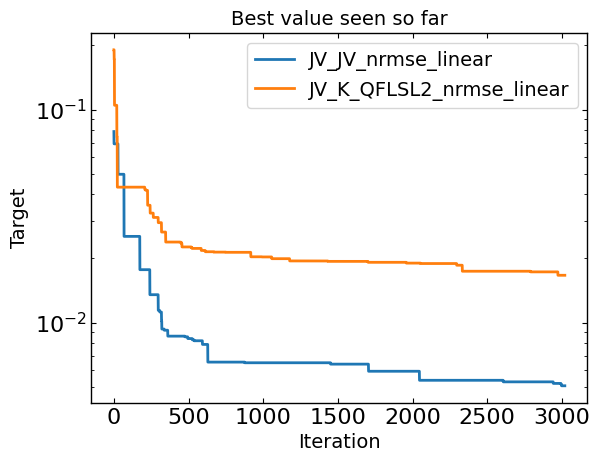

In [9]:
# Plot optimization results
data = ax_client.summarize()
data = optimizer.rescale_dataframe(data, params)
all_metrics = optimizer.all_metrics
plt.figure()
for i, metric in enumerate(all_metrics):
    if jv.minimize[i]:
       plt.plot(np.minimum.accumulate(data[metric]), label=metric)
    else:
       plt.plot(np.maximum.accumulate(data[metric]), label=metric)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target")
plt.legend()
plt.title("Best value seen so far")

plt.show()

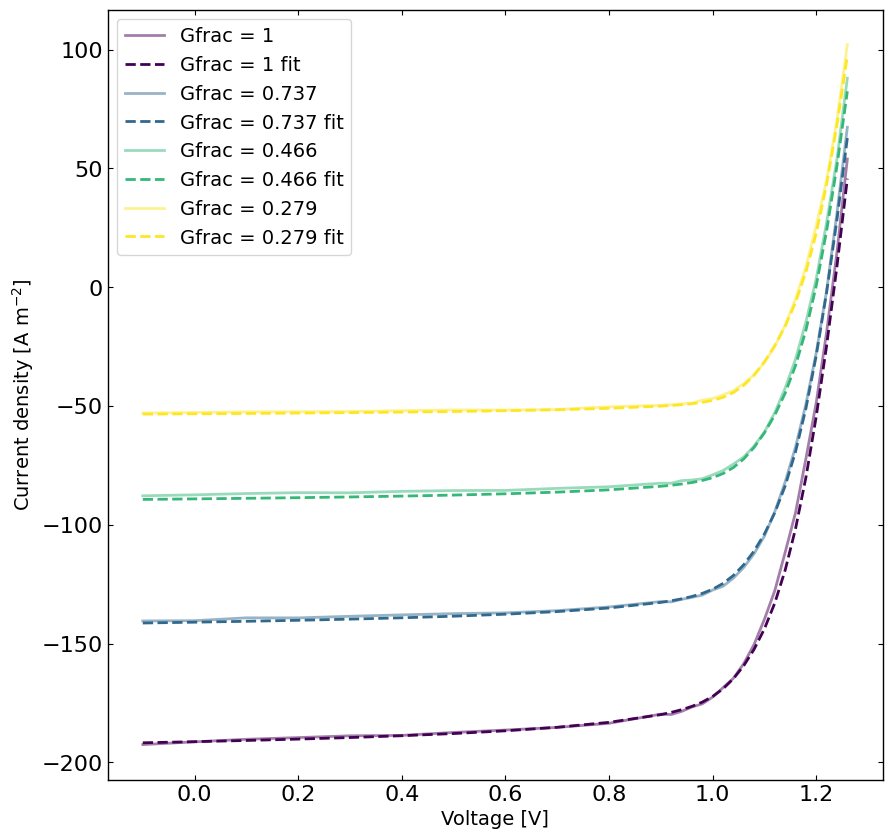

Final NRMSE:  0.00789306379372355


In [10]:
# rerun the simulation with the best parameters
yfit = jv.run(parameters={}) # run the simulation with the best parameters

viridis = plt.get_cmap('viridis', len(Gfracs))
plt.figure(figsize=(10,10))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    plt.plot(X[X[:,1]==Gfrac,0],yfit[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()

from optimpv.general.general import *
# calculate target 
nrmse = calc_metric(y,yfit,metric_name='nrmse')
print('Final NRMSE: ',nrmse)

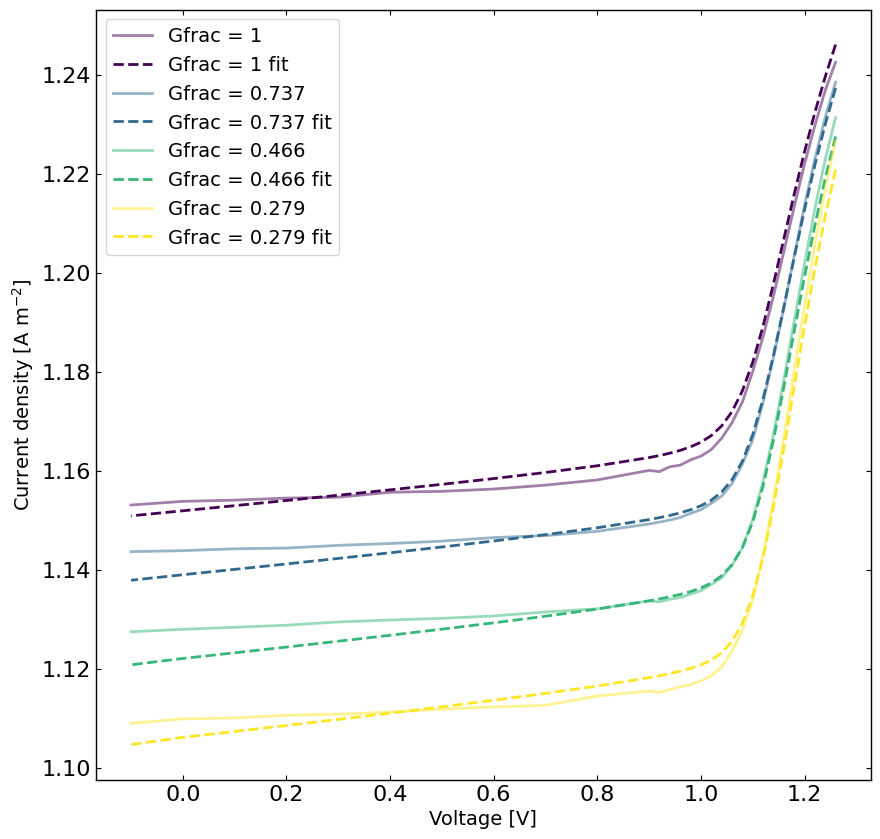

Final NRMSE:  0.018065969396296913


In [11]:
# rerun the simulation with the best parameters
yfit_QFLS = jv.run(parameters={},X=X_QFLS,exp_format='K_QFLSL2') # run the simulation with the best parameters

viridis = plt.get_cmap('viridis', len(Gfracs))
plt.figure(figsize=(10,10))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    plt.plot(X_QFLS[X_QFLS[:,1]==Gfrac,0],y_QFLS[X_QFLS[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    plt.plot(X_QFLS[X_QFLS[:,1]==Gfrac,0],yfit_QFLS[X_QFLS[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()

from optimpv.general.general import *
# calculate target 
nrmse = calc_metric(y_QFLS,yfit_QFLS,metric_name='nrmse')
print('Final NRMSE: ',nrmse)

/home/lecorre/miniconda3/envs/testing/lib/python3.13/site-packages/ax/adapter/transforms/winsorize.py:126: AxOptimizationWarning:

Encountered a `MultiObjective` without objective thresholds. We will winsorize each objective separately. We strongly recommend specifying the objective thresholds when using multi-objective optimization.



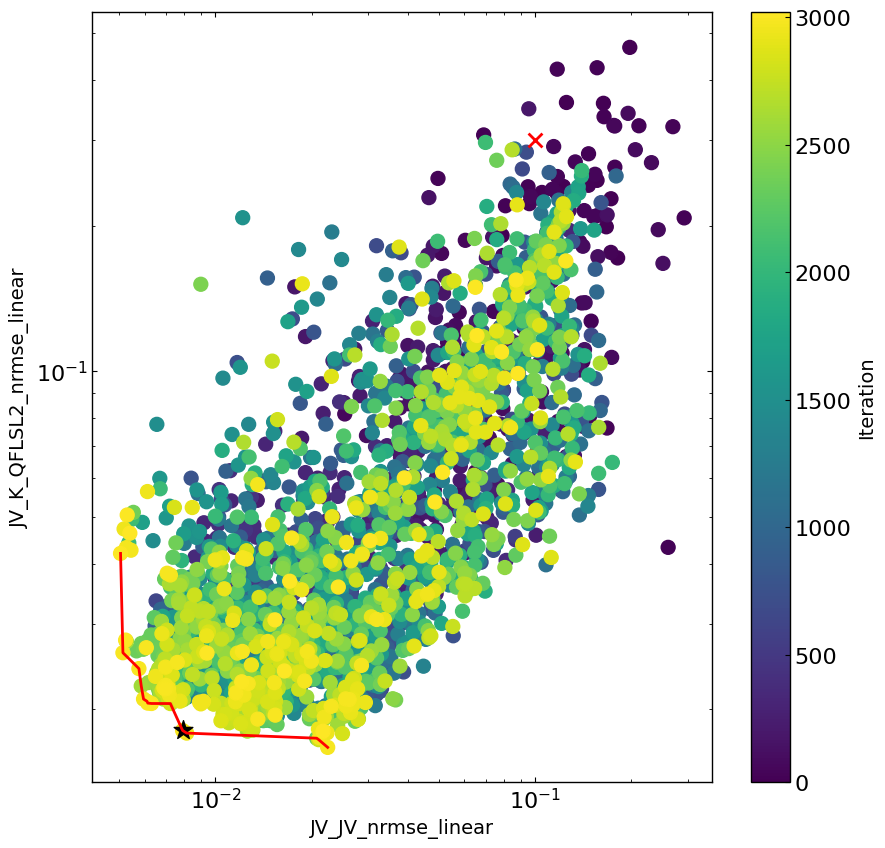

In [12]:
# Plot Pareto frontier
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = ax_client.get_pareto_frontier(use_model_predictions=False)

cm = matplotlib.colormaps.get_cmap('viridis')
df = get_df_from_ax(params, optimizer)
# create pareto df
dum_dic = {}
for eto in pareto:
    for metr in optimizer.all_metrics:
        if metr not in dum_dic.keys():
            dum_dic[metr] = []
        dum_dic[metr].append(eto[1][metr][0])
df_pareto = pd.DataFrame(dum_dic)
dum_dic = jv.run_Ax(parameters={})
best_balanced = [ dum_dic[metr] for metr in optimizer.all_metrics]
for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 
    plt.scatter(t_c[0],t_c[1],c='r', marker='x', s=100) # plot the threshold
    plt.scatter(best_balanced[0],best_balanced[1],c='k', marker='*', s=200, label='Best balanced') # plot the best balanced point
    plt.xlabel(c[0])
    plt.ylabel(c[1])
    plt.xscale('log')
    plt.yscale('log')
    
    
    plt.show()


In [13]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('PTAA',session_path)
sim.clean_up_output('perovskite',session_path)
sim.clean_up_output('C60',session_path)
sim.clean_up_output('simulation_setup_realPerovskite.txt',session_path)